vmax: 11.031825748954233


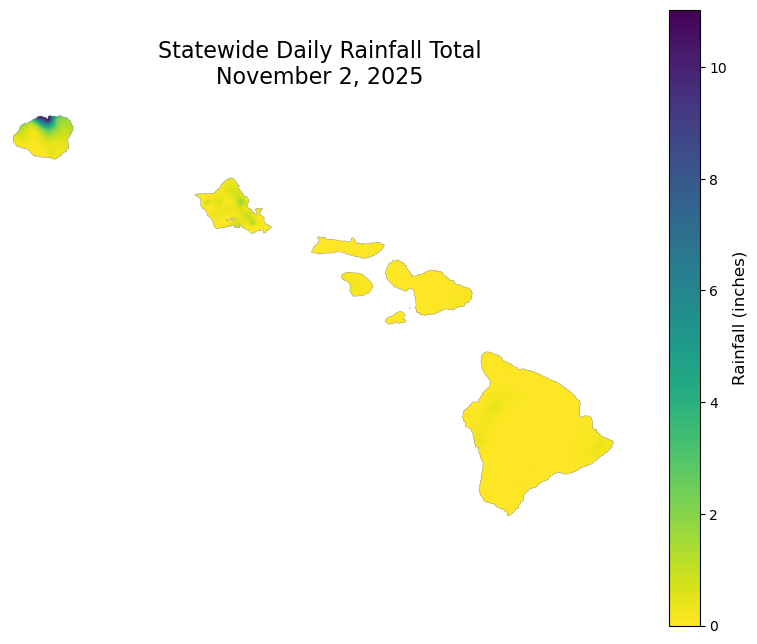

In [17]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
month = 11
date = 2

out_png = f"../../public/climate-summary/{month:02d}_{date:02d}.png"

with rasterio.open(f"rainfall_new_day_statewide_data_map_2025_{month:02d}_{date:02d}.tif") as src:
    data = src.read(1).astype(float)
    nodata = src.nodata
    bounds = src.bounds  

masked = np.ma.masked_where(data == nodata, data) / 25.4

vmax = np.nanmax(masked)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    masked,
    cmap = 'viridis_r',
    extent=(bounds.left, bounds.right, bounds.bottom, bounds.top),
    vmin=0,
    vmax=vmax,
)
print(f"vmax: {vmax}")
ax.set_axis_off()  
title = ax.set_title(f"Statewide Daily Rainfall Total\nNovember {date}, 2025", fontsize=16, pad=20)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Rainfall (inches)", fontsize=12)
fig.savefig(out_png, dpi=300, pad_inches=0.1, bbox_inches='tight')
plt.show()
